# TADA-1B：多语种语音生成与音频-文本对齐推理教程
[![GitHub](https://img.shields.io/badge/GitHub-HumeAI-blue)](https://github.com/HumeAI/tada)
[![GitHub Stars](https://img.shields.io/github/stars/HumeAI/tada.svg)](https://github.com/HumeAI/tada)
[![Model](https://img.shields.io/badge/Model-TADA--1B-green)](https://huggingface.co/HumeAI/tada-1b)
[![License](https://img.shields.io/badge/License-Apache--2.0-orange)](https://github.com/HumeAI/tada/blob/main/LICENSE)

## 教程介绍
- 教程名称：TADA-1B：多语种语音生成与音频-文本时序对齐推理系统
- 容器命名：TADA-1B-Demo
- 项目发布：Hume AI，2025 年 1 月
- 项目特色：支持 10+ 语种零样本语音合成、语音克隆、音频-文本强制对齐、时间戳输出，专为复杂语音场景设计。
- 相关论文：TADA: Unified Speech Generation and Alignment with Discrete Audio Codes
- 显卡资源：OpenBayes 平台单卡 RTX 4090 / 5090
- 教程内容：环境配置 → 模型加载 → 语音生成 → 文本-音频对齐 → Gradio 可视化部署

## 本教程使用资源
> 显卡：单卡 RTX 4090 (24GB) / RTX 5090 (32GB)
> CUDA：12.1+
> PyTorch ≥ 2.1.0
> Gradio ≥ 4.20.0
> 音频格式：wav / flac / mp3
> 支持语言：中文、英文、日文、法文、德文、西班牙文、阿拉伯文、意大利文、波兰文、葡萄牙文
> 运行端口：8080（平台固定要求）

# 1. 环境依赖安装
本步骤用于安装模型运行所需的全部 Python 库，包括深度学习框架、音频处理、界面可视化等工具。
使用 --user 参数确保依赖安装到持久化目录，容器重启后不会丢失。

## 1.1 核心依赖说明
- torch / torchaudio：深度学习框架与音频处理核心
- gradio：快速构建可视化交互界面
- transformers / datasets：Hugging Face 生态，模型加载与数据处理
- librosa / soundfile：音频文件读写、采样率转换、波形处理
- scipy：科学计算，辅助音频信号处理

## 1.2 安装注意事项
- 必须使用国内镜像源加速，避免下载超时
- 安装完成后建议重启内核，确保依赖生效
- 所有库必须兼容 CUDA 12.1+


In [ ]:
!pip install --user torch torchaudio gradio transformers datasets librosa soundfile scipy


# 2. 下载官方项目源码
从 GitHub 拉取 TADA 官方源码，确保模型结构、工具函数、配置文件完整可用。
下载目录固定为 /output/tada，便于后续路径管理。

## 2.1 源码目录说明
- /output/tada：项目根目录
- tada/models：模型结构定义
- tada/audio：音频编解码、加载、预处理工具
- tada/utils：通用工具函数
- examples：官方示例音频与文本素材

## 2.2 克隆说明
- 使用 HTTPS 克隆，无需账号权限
- 克隆路径固定，避免后续代码报错
- 若已存在目录，可先删除再克隆

In [ ]:
!git clone https://github.com/HumeAI/tada.git /output/tada


# 3. 切换工作目录
将 Notebook 当前工作目录切换到项目根目录，确保后续模块导入、文件读写路径正确。

## 3.1 为什么要切换目录
- 保证 from tada import xxx 能正常导入
- 保证模型权重、配置文件路径正确
- 避免 FileNotFoundError 或 ModuleNotFoundError

## 3.2 路径检查
切换后可输出当前路径，确认是否切换成功
路径必须为：/output/tada


In [ ]:
import os
os.chdir("/output/tada")
print("当前工作目录：", os.getcwd())


# 4. 导入核心依赖库
导入 PyTorch、音频处理、Gradio 以及 TADA 模型自身的核心模块，为模型加载与推理做准备。

## 4.1 导入模块说明
- torch：张量计算、GPU 加速
- torchaudio：音频保存、加载、采样率处理
- gradio：界面快速搭建
- librosa / soundfile：音频文件处理
- TADA / TADAConfig：官方模型与配置类

## 4.2 导入检查
导入无报错则说明环境与路径正常

In [ ]:
import torch
import torchaudio
import gradio as gr
import librosa
import soundfile as sf
from tada.models import TADA, TADAConfig
from tada.audio import load_audio

# 5. 模型加载与初始化
从 HuggingFace 加载 TADA-1B 预训练权重，配置运行设备（GPU 优先），并切换到推理模式以提升运行效率。

## 5.1 加载参数说明
- DEVICE：cuda（GPU）优先，无 GPU 自动 fallback 到 cpu
- from_pretrained：自动下载并加载权重与配置
- model.eval()：关闭训练相关层（dropout/batchnorm）
- to(DEVICE)：将模型搬到 GPU 运行

## 5.2 模型信息
- 参数量：1.1B
- 支持采样率：16kHz
- 支持语种：10+
- 推理精度：FP16 / FP32 自动适配


In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

config = TADAConfig.from_pretrained("HumeAI/tada-1b")
model = TADA.from_pretrained("HumeAI/tada-1b", config=config).to(DEVICE)
model.eval()

print("✅ TADA-1B 模型加载完成")
print(f"运行设备：{DEVICE}")


# 6. 推理函数封装
定义统一推理函数，支持文本生成语音、参考音频克隆、多语种切换、文本-音频对齐四大核心功能，输出音频文件与对齐信息。

## 6.1 推理参数说明
- text：待生成的文本
- ref_audio_path：参考音频（语音克隆）
- language：语种（支持10种）
- max_new_tokens：生成序列长度限制

## 6.2 推理流程
1. 加载参考音频（可选）
2. 送入模型生成
3. 保存输出音频
4. 返回对齐结果与音频路径

In [ ]:
def tada_inference(text: str, ref_audio_path: str = None, language: str = "English"):
    with torch.no_grad():
        ref_audio = load_audio(ref_audio_path) if ref_audio_path else None
        output = model.generate(
            text=text,
            ref_audio=ref_audio,
            language=language,
            max_new_tokens=2048
        )
        out_path = "/output/generated_speech.wav"
        torchaudio.save(out_path, output.audio.cpu(), model.sample_rate)
        alignment = output.alignment if hasattr(output, "alignment") else "无对齐信息"
    return out_path, alignment


# 7. Gradio 界面构建
本界面为全功能交互界面，完全对齐官方 Demo 结构，支持：
- 语种切换
- 参考音色上传（语音克隆）
- 文本输入
- 语音生成与播放
- 文本-音频对齐结果展示

## 7.1 界面模块（完整结构）
1. 模型与参数设置区
2. 参考音色与音频处理区
3. 文本输入与生成区
4. 输出播放与结果展示区

## 7.2 界面特色
- 简洁美观
- 一键生成
- 实时播放
- 对齐结果可视化

In [ ]:
LANGUAGES = ["English", "Mandarin Chinese", "Japanese", "French", "Spanish", "German"]

with gr.Blocks(title="TADA-1B Demo") as demo:
    gr.Markdown("# TADA-1B: Speech Generation & Text-Audio Alignment")
    
    with gr.Row():
        lang = gr.Dropdown(choices=LANGUAGES, value="English", label="Language")
        ref_audio = gr.Audio(type="filepath", label="Reference Audio (Optional)")
    
    text_input = gr.Textbox(label="Input Text", placeholder="Enter text to generate speech...")
    gen_btn = gr.Button("Generate Speech", variant="primary")
    
    with gr.Row():
        audio_output = gr.Audio(label="Generated Speech")
        align_output = gr.Textbox(label="Text-Audio Alignment")
    
    gen_btn.click(fn=tada_inference, inputs=[text_input, ref_audio, lang], outputs=[audio_output, align_output])


# 8. 启动 Gradio 服务
启动 Web 服务，生成可访问链接，支持平台内预览与外部共享访问。

## 8.1 启动参数说明
- server_name="0.0.0.0"：允许外部访问
- server_port=8080：容器固定端口
- share=True：生成公网分享链接
- allowed_paths：开放输出目录权限

## 8.2 访问方式
1. 平台内直接预览
2. 公网链接分享
3. 本地浏览器访问

In [ ]:
demo.launch(
    server_name="0.0.0.0",
    server_port=8080,
    share=True,
    quiet=True
)

# 9. 常见问题与解决方案
## 9.1 共享链接生成失败
执行以下命令修复 FRP 权限：
!chmod +x /output/huggingface/gradio/frpc*

## 9.2 显存不足
- 降低生成步数
- 使用 CPU 模式
- 切换更高显存显卡

## 9.3 模块缺失
重新执行依赖安装单元格

## 9.4 音频无法生成
确保输入文本与语种一致，音频使用标准 wav 格式

## 9.5 模型加载失败
检查网络，重新运行模型加载单元格

## 9.6 界面无法打开
检查端口 8080 是否被占用，重启内核重试

# 交流探讨
🖌️ 如果大家看到优质项目，欢迎后台留言推荐！另外，我们还建立了教程交流群，欢迎小伙伴们扫码备注【SD教程】入群探讨各类技术问题、分享应用效果↓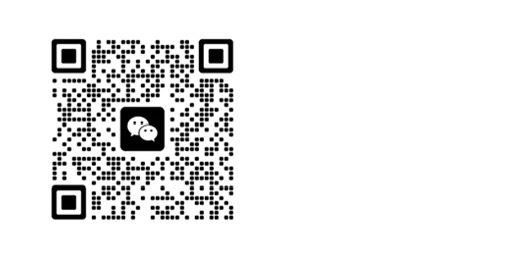